# DCGAN for Drinks

Prompt:
<b> I want to use this new dataset to train a DCGAN. </b>
- Remember it's a DCGAN. So I will need a deep generator and discriminator.
- Use best practices if I need to do any kind of cleaning on the images before sending them out. Everything from load to end should be done with tensorflow

OpenAI. (2025). Training a DCGAN [ChatGPT response]. OpenAI. Retrieved March 22, 2025, from https://chat.openai.com

In [3]:
import json
import os
import tensorflow as tf
import pandas as pd
from pathlib import Path
import shutil

In [4]:
PHOTOS_DIR = 'data/photos'
JSON_PATH = 'data/photos.json'

df_photos = pd.read_json('data/photos.json', lines=True)

In [5]:
df_photos['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

In [6]:
df_photos.groupby(['label']).size()

label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
dtype: int64

In [7]:
SOURCE_DIR = Path("data/photos")
DEST_DIR = Path("data/drinks")
#DEST_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
df_drinks = df_photos[df_photos['label'] == 'drink']

#for photo_id in df_drinks['photo_id']:
#    src = SOURCE_DIR / f"{photo_id}.jpg"
#    dst = DEST_DIR / f"{photo_id}.jpg"
#    if src.exists():
#        shutil.copy(src, dst)

# Save filtered JSON
df_drinks.to_json("data/drinks.json", orient="records", lines=True)

In [9]:
# Config
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 64  # You can adjust based on GPU memory
BUFFER_SIZE = 10000
DATA_DIR = Path("data/drinks")

# Preprocess each image
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (image / 127.5) - 1  # Normalize to [-1, 1] for tanh
    return image

# Load dataset using tf.data
def load_dataset():
    files = tf.data.Dataset.list_files(str(DATA_DIR / "*.jpg"), shuffle=True)
    dataset = files.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Instantiate
train_dataset = load_dataset()


I0000 00:00:1742686226.672983    9451 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9511 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [10]:
def make_generator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(4*4*512, use_bias=False, input_shape=(100,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Reshape((4, 4, 512)),

        tf.keras.layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False),  # 8x8
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),  # 16x16
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),   # 32x32
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(32, 5, strides=2, padding='same', use_bias=False),   # 64x64
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(3, 5, strides=2, padding='same', use_bias=False, activation='tanh')  # 128x128x3
    ])
    return model

generator = make_generator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
def make_discriminator_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, 5, strides=2, padding='same', input_shape=[128, 128, 3]),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Conv2D(128, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Conv2D(256, 5, strides=2, padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

discriminator = make_discriminator_model()

/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    # Instead of 1.0 for real
    real_labels = tf.ones_like(real_output) * 0.9
    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [13]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.4)
discriminator_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.4)

In [14]:
import time
import os
from matplotlib import pyplot as plt

EPOCHS = 300
NOISE_DIM = 100
NUM_EXAMPLES_TO_GENERATE = 16
CHECKPOINT_DIR = './training_checkpoints'
OUTPUT_IMAGE_DIR = './generated_images'

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)
manager = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)


In [15]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [16]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0  # Rescale to [0, 1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_IMAGE_DIR}/epoch_{epoch:04d}.png')
    plt.close()

In [17]:
from tqdm import tqdm

In [18]:
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()
        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        print(f"\nEpoch {epoch}/{epochs}")
        for image_batch in tqdm(dataset, desc=f"Training Epoch {epoch}"):
            gen_loss, disc_loss = train_step(image_batch)
            gen_loss_avg.update_state(gen_loss)
            disc_loss_avg.update_state(disc_loss)

        # Generate sample images
        generate_and_save_images(generator, epoch, seed)

        # Save checkpoints
        if epoch % 10 == 0:
            manager.save()

        print(f"Gen Loss: {gen_loss_avg.result():.4f}, Disc Loss: {disc_loss_avg.result():.4f}, Time: {time.time() - start:.2f}s")

In [19]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_DISABLE_LAYOUT'] = '1'

tf.get_logger().setLevel('ERROR')

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='PIL')

In [18]:
train(train_dataset, EPOCHS)


Epoch 1/100


Training Epoch 1:   0%|                                                                            | 0/245 [00:00<?, ?it/s]2025-03-22 18:20:00.314976: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:02.771768: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:03.078420: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:03.305961: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:03.830437: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:04.365051: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:07.332764: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:09.510598: E tensorflow/core/grappler/optimizers

Gen Loss: 1.3029, Disc Loss: 1.0553, Time: 34.61s

Epoch 2/100


Training Epoch 2:   0%|                                                                            | 0/245 [00:00<?, ?it/s]2025-03-22 18:20:37.127852: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:37.157892: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:37.351968: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:38.594001: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:38.706822: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 18:20:41.988254: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 2: 100%|██████████████████████████████████████████████████████████████████| 245/245 [00:27<00:00,  8.90it/s]


Gen Loss: 1.1183, Disc Loss: 1.2192, Time: 27.78s

Epoch 3/100


...

Gen Loss: 1.5327, Disc Loss: 0.9904, Time: 39.83s

Epoch 99/100


Training Epoch 99:   0%|                                                                           | 0/245 [00:00<?, ?it/s]2025-03-22 19:19:56.461807: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:19:57.192556: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:19:58.101585: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:19:58.898754: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:00.662981: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:01.719313: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 99: 100%|█████████████████████████████████████████████████████████████████| 245/245 [00:34<00:00,  7.17it/s]


Gen Loss: 1.6527, Disc Loss: 0.9834, Time: 34.49s

Epoch 100/100


Training Epoch 100:   0%|                                                                          | 0/245 [00:00<?, ?it/s]2025-03-22 19:20:29.560021: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:29.797481: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:30.538915: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:34.650020: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:34.680020: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:34.849158: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
2025-03-22 19:20:35.864868: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: known incorrect sRGB profile
Training Epoch 100: 100%|████████████████████████████████████████

Gen Loss: 1.5913, Disc Loss: 0.9505, Time: 31.97s


<b> I used another prompt for the next step:
- now I need to Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model
- and plot 5 generated images in jupyter lab

In [22]:
import tensorflow_gan as tfgan

# Resize to 299x299 for InceptionV3
def preprocess_for_inception(images):
    return tf.image.resize(images, [299, 299])

def calculate_inception_score(images):
    images = preprocess_for_inception(images)
    return tfgan.eval.classifier_score_from_logits(
        tfgan.eval.run_inception(images, output_tensor='logits:0')).numpy()

def calculate_fid(real_images, fake_images):
    real_images = preprocess_for_inception(real_images)
    fake_images = preprocess_for_inception(fake_images)

    real_activations = tfgan.eval.run_inception(real_images, output_tensor='pool_3:0')
    fake_activations = tfgan.eval.run_inception(fake_images, output_tensor='pool_3:0')

    return tfgan.eval.frechet_classifier_distance_from_activations(
        real_activations, fake_activations).numpy()




Failed to import TensorFlow. Please note that TensorFlow is not installed by default when you install TensorFlow Probability. This is so that users can decide whether to install the GPU-enabled TensorFlow package. To use TensorFlow Probability, please install the most recent version of TensorFlow, by following instructions at https://tensorflow.org/install.




Failed to import TensorFlow Probability. To use TF-GAN, please install the most recent version of TensorFlow Probability, by following instructions at https://www.tensorflow.org/probability/install.




ImportError: cannot import name 'check_pinned' from 'tensorflow.python.ops.gen_experimental_dataset_ops' (/home/leandro-sartini/miniconda3/envs/work/lib/python3.10/site-packages/tensorflow/python/ops/gen_experimental_dataset_ops.py)

In [23]:
import matplotlib.pyplot as plt

def plot_generated_images(generator, num_images=5):
    noise = tf.random.normal([num_images, 100])
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1.0) / 2.0  # Rescale to [0, 1]

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(generated_images[i])
        plt.axis('off')
    plt.show()


W0000 00:00:1742685902.167063    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.174461    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.182867    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.187015    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.194920    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.200444    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.209606    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.215553    4861 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1742685902.220554    4861 gp

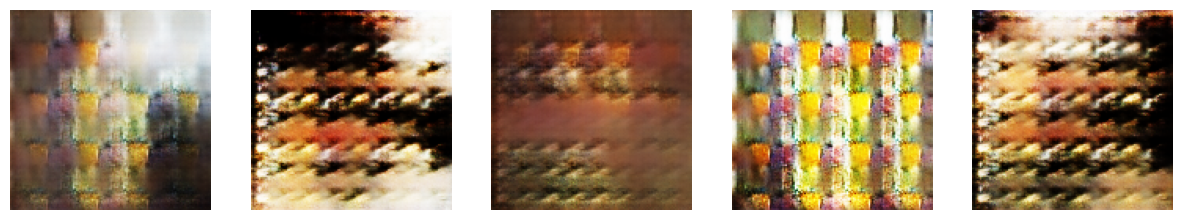

In [24]:
plot_generated_images(generator)